In [ ]:
!wget https://www.cse.wustl.edu/~jain/ehms/ftp/wustl-ehms-2020_with_attacks_categories.csv
!pip install xgboost numpy shap scikit-learn matplotlib
!pip install adversarial-robustness-toolbox

                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263



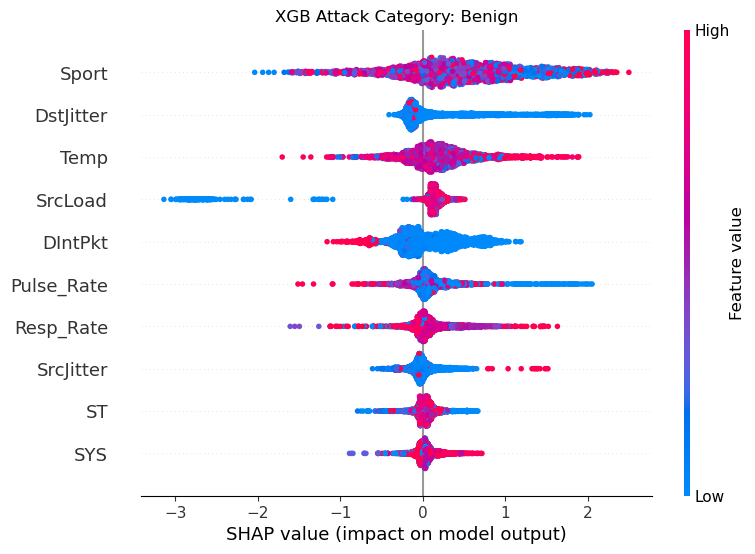

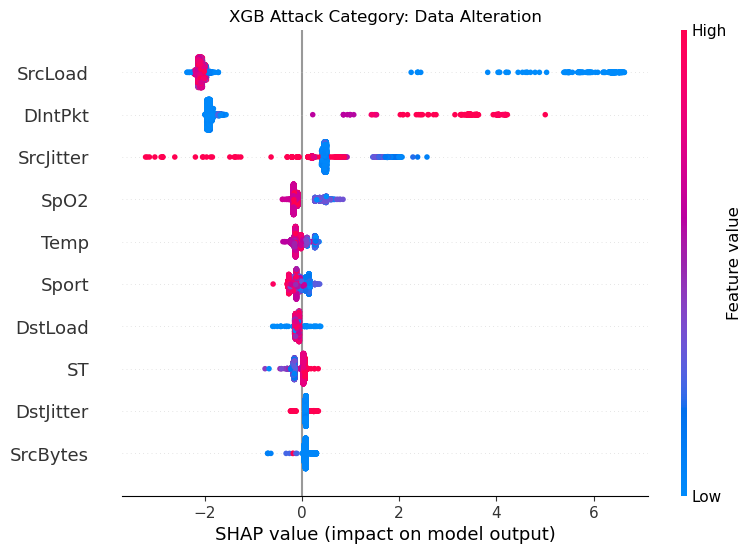

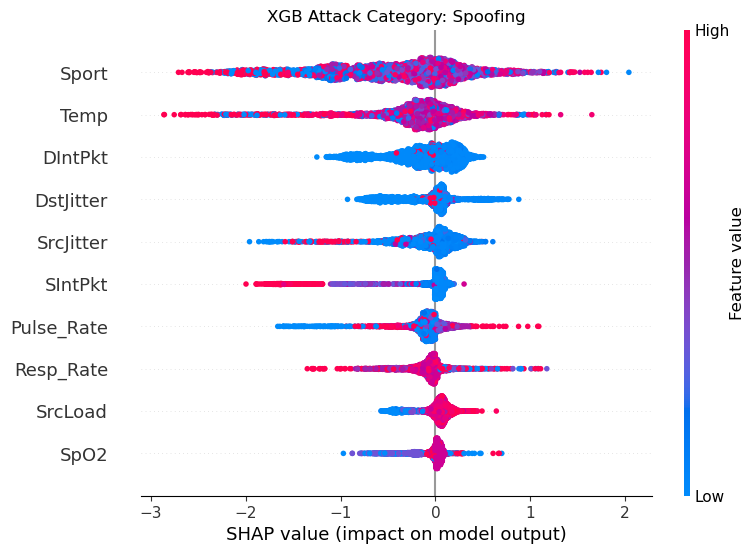

In [352]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb

# Load & preprocess
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac', 'Dir', 'Label', 'Flgs', 'Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)

# Label encoding
for col in ['Attack Category', 'DstMac', 'SrcAddr', 'DstAddr', 'Sport']:
    df[col] = LabelEncoder().fit_transform(df[col])

X, y = df.drop(columns='Attack Category'), df['Attack Category']

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Train & evaluate
model = xgb.XGBClassifier(objective="binary:logistic")
model.fit(X_trainN, y_train)
print(classification_report(y_test, model.predict(X_testN), target_names=['Benign', 'Data Alteration', 'Spoofing']))

# SHAP analysis
explainer = shap.Explainer(model)
shap_vals = explainer.shap_values(X_testN)

# Summary plots for each class
class_names = ['Benign', 'Data Alteration', 'Spoofing']
for i, name in enumerate(class_names):
    shap.summary_plot(shap_vals[:, :, i], X_test, show=False, max_display=10)
    plt.title(f"XGB Attack Category: {name}")
    plt.show()

In [353]:
import numpy as np
import shap

# 1) Build a TreeExplainer and get an Explanation object
explainer = shap.TreeExplainer(model)
shap_exp = explainer(X_testN)                # shap_exp.values.shape == (n_samples, n_features, n_classes)

# 2) Pull out the raw NumPy array
shap_vals = shap_exp.values

# 3) Predictions & mask for Spoodinf FNs (class index=2)
y_pred    = model.predict(X_testN)
fn_mask   = (y_test.values == 2) & (y_pred != 2)

# 4) Slice for only the FN rows **and** only the Spoofing class
#    shap_vals[:, :, 1] has shape (n_samples, n_features)
shap_fn    = shap_vals[:, :, 2][fn_mask]      # now shape = (n_FN, n_features)

# 5) Compute mean |SHAP| per feature
mean_abs  = np.mean(np.abs(shap_fn), axis=0)

# 6) Rank and select top‑3
feature_names = X_testN.columns
top_idx       = np.argsort(mean_abs)[-3:][::-1]
print("Top 3 features driving false negatives (Data Alteration):")
for i in top_idx:
    print(f"  • {feature_names[i]} (mean |SHAP| = {mean_abs[i]:.4f})")


Top 3 features driving false negatives (Data Alteration):
  • Sport (mean |SHAP| = 0.5463)
  • Temp (mean |SHAP| = 0.2733)
  • SrcJitter (mean |SHAP| = 0.2330)


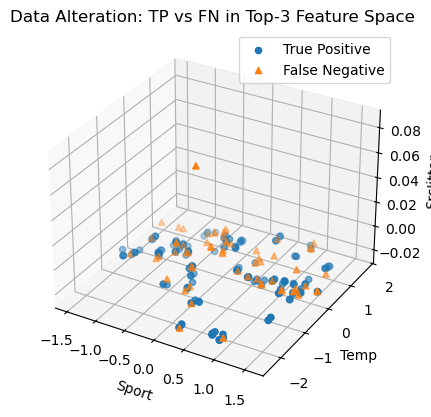

In [354]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

top_features = ['Sport', 'Temp', 'SrcJitter']

# —— ASSUMING YOU’VE ALREADY——
# • determined `top_features` as a list of your three feature names, e.g.
#     top_features = ['feat_A', 'feat_B', 'feat_C']
# • computed `y_pred = model.predict(X_testN)`
# • have your true labels `y_test`

# 1) Build masks for TP and FN in the Spoofing class (index=2)
tp_mask = (y_test.values == 2) & (y_pred == 2)
fn_mask = (y_test.values == 2) & (y_pred != 2)

# 2) Extract the 3‑D coordinates for each set
coords_tp = X_testN.loc[tp_mask, top_features].values  # shape=(n_TP, 3)
coords_fn = X_testN.loc[fn_mask, top_features].values  # shape=(n_FN, 3)

# 3) Plot
fig = plt.figure()
ax  = fig.add_subplot(projection='3d')

# True Positives
ax.scatter(
    coords_tp[:, 0], coords_tp[:, 1], coords_tp[:, 2],
    marker='o', label='True Positive'
)

# False Negatives
ax.scatter(
    coords_fn[:, 0], coords_fn[:, 1], coords_fn[:, 2],
    marker='^', label='False Negative'
)

# 4) Labels & legend
ax.set_xlabel(top_features[0])
ax.set_ylabel(top_features[1])
ax.set_zlabel(top_features[2])
ax.set_title("Data Alteration: TP vs FN in Top‑3 Feature Space")
ax.legend()

plt.show()


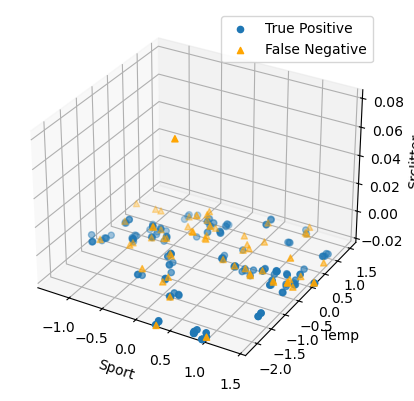

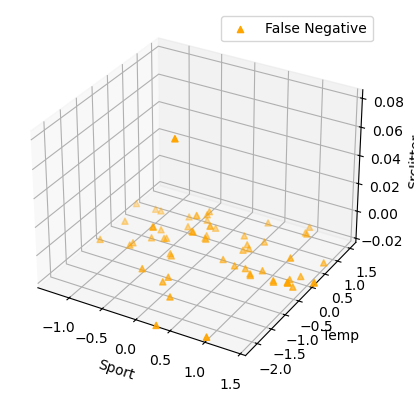

In [355]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

top_features = ['Sport', 'Temp', 'SrcJitter']

# 1) Build masks for TP and FN in the Spoofing class (index=2)
tp_mask = (y_test.values == 2) & (y_pred == 2)
fn_mask = (y_test.values == 2) & (y_pred != 2)

# 2) Extract the 3‑D coordinates for each set
coords_tp = X_testN.loc[tp_mask, top_features].values
coords_fn = X_testN.loc[fn_mask, top_features].values

# 3) Compute axis limits from the SAME points (TP + FN)
all_coords = np.vstack([coords_tp, coords_fn])
xlim = (all_coords[:, 0].min(), all_coords[:, 0].max())
ylim = (all_coords[:, 1].min(), all_coords[:, 1].max())
zlim = (all_coords[:, 2].min(), all_coords[:, 2].max())





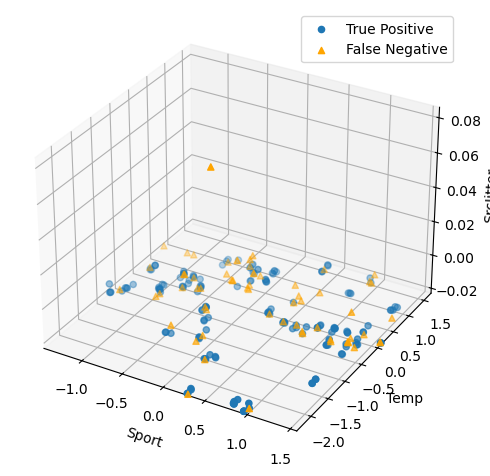

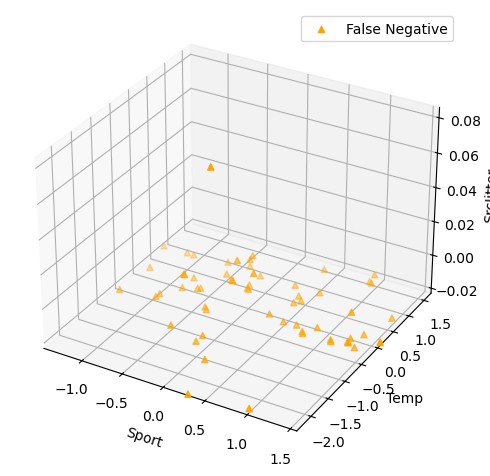

In [378]:
# 4) Plot 1: TP vs FN (with FN in orange)
fig1 = plt.figure()
ax1 = fig1.add_subplot(projection='3d')
ax1.scatter(*coords_tp.T,
            marker='o',
            label='True Positive')
ax1.scatter(*coords_fn.T,
            marker='^',
            color='orange',
            label='False Negative')
ax1.set_xlabel(top_features[0])
ax1.set_ylabel(top_features[1])
ax1.set_zlabel(top_features[2])
ax1.set_xlim(xlim); ax1.set_ylim(ylim); ax1.set_zlim(zlim)
ax1.legend()
fig1.tight_layout()
fig1.savefig("3d_tp_vs_fn_plot_spoofing.pdf", format='pdf')

# 5) Plot 2: Only FN (orange)
fig2 = plt.figure()
ax2 = fig2.add_subplot(projection='3d')
ax2.scatter(*coords_fn.T,
            marker='^',
            color='orange',
            label='False Negative')
ax2.set_xlabel(top_features[0])
ax2.set_ylabel(top_features[1])
ax2.set_zlabel(top_features[2])
ax2.set_xlim(xlim); ax2.set_ylim(ylim); ax2.set_zlim(zlim)
ax2.legend()
fig2.tight_layout()
fig2.savefig("3d_fn_only_plot_spoofing.pdf", format='pdf')

plt.show()

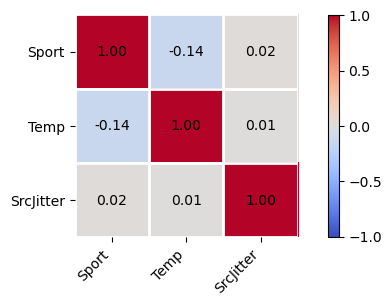

In [356]:
import matplotlib.pyplot as plt
import numpy as np

# … assume corr_df and top_features are already defined …

fig, ax = plt.subplots(figsize=(4, 4))

# 1) draw the heatmap
cax = ax.imshow(
    corr_df.values,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    aspect='equal'
)

# 2) ticks & labels
ax.set_xticks(np.arange(len(top_features)))
ax.set_yticks(np.arange(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha='right')
ax.set_yticklabels(top_features)

# 3) white gridlines between cells
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-.5, len(top_features), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(top_features), 1), minor=True)
ax.grid(which='minor', color='w', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# 4) annotations
for i in range(len(top_features)):
    for j in range(len(top_features)):
        ax.text(j, i, f"{corr_df.iat[i, j]:.2f}",
                ha='center', va='center')

# 5) title
#ax.set_title("Correlation Matrix of Top 3 Features", pad=10)

# 6) colorbar, with extra pad
cbar = fig.colorbar(
    cax,
    shrink=0.7,
    ticks=[-1, -0.5, 0, 0.5, 1],
    pad=0.1          # <-- bump this up for more space
)

# 7) tidy up layout & shift the top down
plt.tight_layout()
plt.subplots_adjust(top=0.88)   # <-- lower this to give more room for title

# 8) save to PDF
fig.savefig("correlation_matrix_spoofing.pdf", format="pdf", bbox_inches="tight")
# (or change the filename/path as you like)

# (Optional) display interactively
# plt.show()


In [357]:
from sklearn.metrics import classification_report

class_names = ['Benign', 'Data Alteration', 'Spoofing']

σ = X_testN['Sport'].std()
δ = 1* σ

X_adv = X_testN.copy()
is_spoofing = (y_test.values == 2)
X_adv.loc[is_spoofing, 'Temp'] += δ

y_adv_pred = model.predict(X_adv)

print("=== Original on Test Set ===")
print(classification_report(y_test, model.predict(X_testN), target_names=class_names))

print("\n=== After Perturbing feature by +0.5σ on Spoofing Samples ===")
print(classification_report(y_test, y_adv_pred, target_names=class_names))


=== Original on Test Set ===
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263


=== After Perturbing feature by +0.5σ on Spoofing Samples ===
                 precision    recall  f1-score   support

         Benign       0.94      0.99      0.97      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.79      0.25      0.37       240

       accuracy                           0.94      3263
      macro avg       0.91      0.74      0.78      3263
   weighted avg       0.93      0.94      0.92      3263



In [358]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import classification_report

# # === Configuration ===
# class_names = ['Benign', 'Data Alteration', 'Spoofing']
# spoof_class = 2  # index of "Spoofing" in your label encoding
# features = ["Sport", "Temp", "SrcJitter"]
# alphas = [0.1, 0.5, 1, 10, 100]  # perturbation multiples of σ

# # Original performance
# print("=== Original on Test Set ===")
# print(classification_report(
#     y_test,
#     model.predict(X_testN),
#     target_names=class_names
# ))

# # Iterate over features & alpha values
# for feat in features:
#     σ = X_testN[feat].std()

#     for α in alphas:
#         δ = α * σ

#         # Build adversarial set
#         X_adv = X_testN.copy()
#         is_spoof = (y_test.values == spoof_class)
#         X_adv.loc[is_spoof, feat] += δ

#         # Predict & report
#         y_adv_pred = model.predict(X_adv)

#         print(f"\n=== Perturbing {feat} by +{α}σ (δ={δ:.4f}) on Spoofing Samples ===")
#         print(classification_report(
#             y_test,
#             y_adv_pred,
#             target_names=class_names
#         ))


In [359]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

=== Original Metrics ===
Accuracy: 97.40%
                 precision    recall  f1-score   support

         Benign       0.98      0.99      0.99      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.92      0.72      0.81       240

       accuracy                           0.97      3263
      macro avg       0.96      0.90      0.93      3263
   weighted avg       0.97      0.97      0.97      3263


XAI-driven attack success on Spoofing: 59.58%

=== After XAI-driven Perturbation ===
Accuracy: 93.14%
Spoofing misclassification rate: 85.42%
                 precision    recall  f1-score   support

         Benign       0.93      0.99      0.96      2827
Data Alteration       0.99      0.99      0.99       196
       Spoofing       0.69      0.15      0.24       240

       accuracy                           0.93      3263
      macro avg       0.87      0.71      0.73      3263
   weighted avg       0.92      0.93      0.91      3263



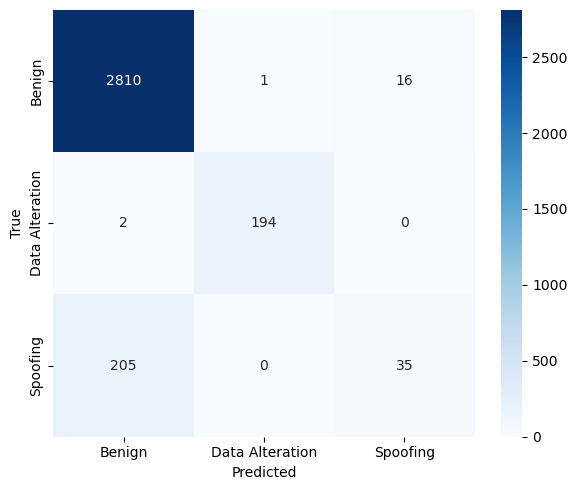

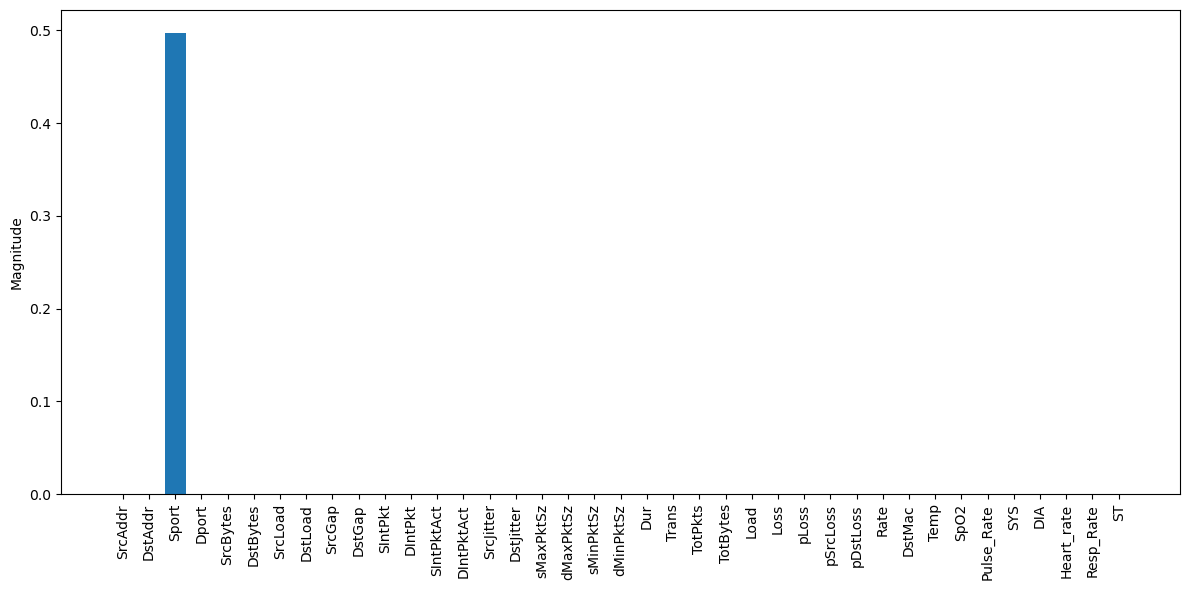

In [360]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from art.utils import compute_success
from art.estimators.classification import XGBoostClassifier

# 1. Load and preprocess data
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')
df['Attack Category'] = df['Attack Category'].replace('normal', 'Benign')
df.drop(columns=['SrcMac', 'Dir', 'Label', 'Flgs', 'Packet_num'], inplace=True)
df.drop(index=[10633, 7923, 8412], inplace=True)
for c in ['Attack Category', 'DstMac', 'SrcAddr', 'DstAddr', 'Sport']:
    df[c] = LabelEncoder().fit_transform(df[c])

X, y = df.drop(columns='Attack Category'), df['Attack Category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_trainN = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_testN = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
num_classes = len(y.unique())

# 2. Train XGBoost
model = xgb.XGBClassifier(objective="binary:logistic", eval_metric='logloss')
model.fit(X_trainN, y_train)

# Original predictions and metrics
y_pred_orig = model.predict(X_testN)
orig_acc = accuracy_score(y_test, y_pred_orig)
print("=== Original Metrics ===")
print(f"Accuracy: {orig_acc:.2%}")
print(classification_report(
    y_test, y_pred_orig, target_names=['Benign','Data Alteration','Spoofing']
))

# top 3 features = ["Sport", "Temp", "SrcJitter"]

# 3. XAI-driven adversarial perturbation on 'SrcLoad'
sigma = X_testN['Sport'].std()
delta = 0.5 * sigma
X_adv_xai = X_testN.copy()
mask_da = (y_test.values == 2)
X_adv_xai.loc[mask_da, 'Sport'] += delta

# Wrap model for ART
min_val, max_val = X_trainN.values.min(), X_trainN.values.max()
art_model = XGBoostClassifier(
    model=model,
    clip_values=(min_val, max_val),
    nb_classes=num_classes,
    nb_features=X_trainN.shape[1]
)

# Compute ART success rate for Data Alteration
y_clean_da = X_testN.to_numpy()[mask_da]
y_adv_da = X_adv_xai.to_numpy()[mask_da]
labels_da = y_test.to_numpy()[mask_da]
sr_data_alter = compute_success(
    classifier=art_model,
    x_clean=y_clean_da,
    labels=labels_da,
    x_adv=y_adv_da,
    targeted=False,
    batch_size=32
)
print(f"\nXAI-driven attack success on Spoofing: {sr_data_alter*100:.2f}%")

# 4. Metrics on perturbed set
y_pred_adv = model.predict(X_adv_xai)
adversarial_acc = accuracy_score(y_test, y_pred_adv)
da_success = np.mean(y_pred_adv[mask_da] != y_test.to_numpy()[mask_da])
print("\n=== After XAI-driven Perturbation ===")
print(f"Accuracy: {adversarial_acc:.2%}")
print(f"Spoofing misclassification rate: {da_success*100:.2f}%")
print(classification_report(
    y_test, y_pred_adv, target_names=['Benign','Data Alteration','Spoofing']
))

# 5. Confusion matrix plot (saved as PDF)
conf = confusion_matrix(y_test, y_pred_adv)
plt.figure(figsize=(6,5))
sns.heatmap(
    conf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign','Data Alteration','Spoofing'],
    yticklabels=['Benign','Data Alteration','Spoofing']
)
#plt.title('Confusion Matrix after XAI-driven Perturbation')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
# save to PDF
plt.savefig('confusion_matrix_spoofing.pdf')
plt.show()
plt.close()  # close the figure to free memory



# 6. Feature perturbation magnitude (average on DA samples, saved as PDF)
delta_feat = X_adv_xai.to_numpy() - X_testN.to_numpy()
mean_delta = np.mean(np.abs(delta_feat)[mask_da], axis=0)
plt.figure(figsize=(12,6))
plt.bar(X.columns, mean_delta)
plt.xticks(rotation=90)
#plt.title('Average Feature Perturbation (XAI-driven, Spoofing samples)')
plt.ylabel('Magnitude')
plt.tight_layout()
# save to PDF
plt.savefig('feature_perturbation_magnitude_spoofing.pdf')
plt.show()
plt.close()


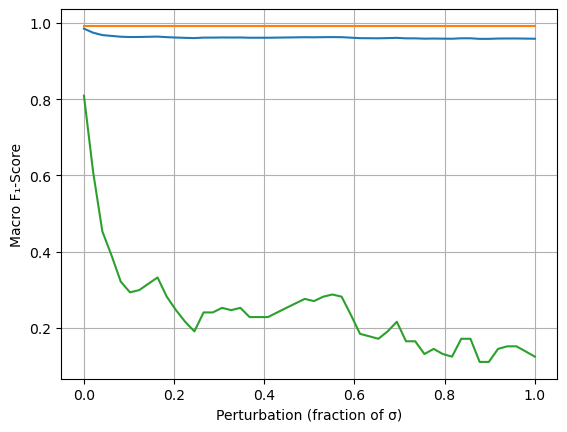

In [361]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

#feature = 'SrcLoad' # ← for Data Alteration
feature = 'Sport'  # ← for Spoofing

sigma = X_testN[feature].std()
perturbations = np.linspace(0.0, 1, 50)

f1_scores = []

for p in perturbations:
    delta = p * sigma
    X_adv = X_testN.copy()
    mask_da = (y_test.values == 2) ## CLASS MASK 1 = DA 2 = S
    X_adv.loc[mask_da, feature] += delta

    # Predict
    y_pred = model.predict(X_adv)

    # Compute and store macro F1
    f1 = f1_score(y_test, y_pred, average=None)
    f1_scores.append(f1)

# Finally, plot the F1‐score curve
plt.figure()
plt.plot(perturbations, f1_scores)
plt.xlabel('Perturbation (fraction of σ)')
plt.ylabel('Macro F₁-Score')
#plt.title(f'F₁-Score vs. Adversarial Perturbation on {feature}')
plt.grid(True)

# To save as PDF, uncomment one of these lines:
# plt.savefig('f1_vs_perturbation.pdf', format='pdf', bbox_inches='tight')
plt.savefig('f1_vs_perturbation_Spoofing.pdf', dpi=300, bbox_inches='tight')

plt.show()

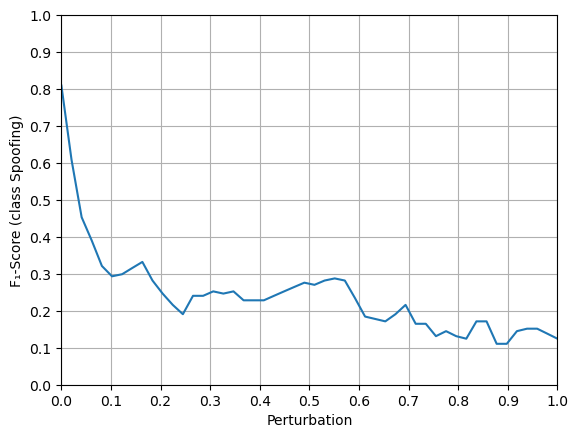

In [362]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#feature = 'SrcLoad' # ← for Data Alteration
feature = 'Sport'  # ← for Spoofing

sigma = X_testN[feature].std()
perturbations = np.linspace(0.0, 1, 50)

f1_scores_class2 = []   # store only class‐2 F₁

for p in perturbations:
    delta = p * sigma
    X_adv = X_testN.copy()
    mask_da = (y_test.values == 2) ## CLASS MASK 1 = DA 2 = S
    X_adv.loc[mask_da, feature] += delta

    # Predict
    y_pred = model.predict(X_adv)

    # Compute all per-class F₁s, then grab index 2
    f1_all = f1_score(y_test, y_pred, average=None)
    f1_scores_class2.append(f1_all[2])

# Finally, plot the class‐2 F₁‐score curve
plt.figure()
plt.plot(perturbations, f1_scores_class2)
plt.xlabel('Perturbation')
plt.ylabel('F₁-Score (class Spoofing)')
#plt.title(f'Class 2 F₁ vs. Adversarial Perturbation on {feature}')
plt.grid(True)

# … after plotting …
plt.ylim(0, 1)               # force the y‑axis between 0 and 1
plt.yticks(np.linspace(0, 1, 11))  # optional: nicer ticks every 0.1

plt.xlim(0, 1)               # force the y‑axis between 0 and 1
plt.xticks(np.linspace(0, 1, 11))  # optional: nicer ticks every 0.1

# To save as PDF:
plt.savefig('f1score_vs_perturbation_Spoofing.pdf', dpi=300, bbox_inches='tight')

plt.show()


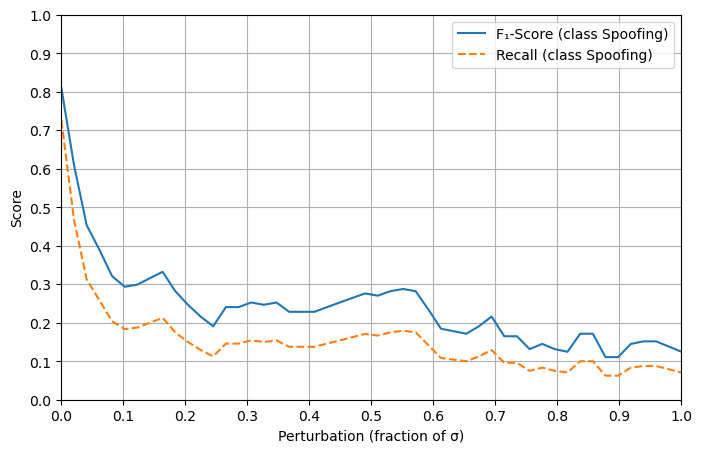

In [387]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score

# feature = 'SrcLoad'  # ← for Data Alteration
feature = 'Sport'      # ← for Spoofing

sigma = X_testN[feature].std()
perturbations = np.linspace(0.0, 1, 50)

f1_scores_class2 = []
recall_scores_class2 = []

for p in perturbations:
    delta = p * sigma
    X_adv = X_testN.copy()
    mask_spoof = (y_test.values == 2)  # CLASS MASK: 1 = DA, 2 = Spoofing
    X_adv.loc[mask_spoof, feature] += delta

    # Predict
    y_pred = model.predict(X_adv)

    # Compute per-class F₁ and recall
    f1_all = f1_score(y_test, y_pred, average=None)
    recall_all = recall_score(y_test, y_pred, average=None)

    # Grab the Spoofing class (index 2)
    f1_scores_class2.append(f1_all[2])
    recall_scores_class2.append(recall_all[2])

# Plot both curves
plt.figure(figsize=(8, 5))
plt.plot(perturbations, f1_scores_class2, label='F₁-Score (class Spoofing)')
plt.plot(perturbations, recall_scores_class2, linestyle='--', label='Recall (class Spoofing)')
plt.xlabel('Perturbation (fraction of σ)')
plt.ylabel('Score')
#plt.title(f'Class 2 F₁-Score and Recall vs. Adversarial Perturbation on {feature}')
plt.grid(True)
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.xticks(np.linspace(0, 1, 11))
plt.legend(loc='upper right')

# Save as PDF
plt.savefig('f1_recall_vs_perturbation_Spoofing.pdf', dpi=300, bbox_inches='tight')
plt.show()
